# ClimateNet AR Analysis: Compare reanalysis data

## Data notes
### ERA5
- Monthly ERA5 TCW and TCWV is here: `/gdex/data/d633001/e5.moda.an.sfc/` in yearly folders under ``*tcw*.nc`` - which one do I want to compare with MERRA?
- Note that ARTMIP ERA source data labels tcwv as IWV in `/glade/campaign/collections/rda/data/d651018/ERA5`
- So I will use TCWV from ERA5 but also noted they (TCW and TCWV) are very similar.
### MERRA-2
- Can't find monthly MERRA-2 water vapor in GDEX, 3-hourly ARTMIP source data is in `/glade/campaign/collections/rda/data/d651012/merra2_2000-2017` which uses IWV as the variable name.
- Turns out this is computed IWV from Q and not the right thing to compare with ERA TCWV.
- Instead, download monthly MERRA TQV to compare using this source: https://disc.gsfc.nasa.gov/datasets/M2TMNXSLV_5.12.4/summary

## Import packages

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import xesmf as xe
import nc_time_axis
import cftime 
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
import matplotlib.colors as mcolors
import matplotlib as mpl
import datetime
import pandas as pd

In [2]:
# Import dask
import dask

# Use dask jobqueue
from dask_jobqueue import PBSCluster

# Import a client
from dask.distributed import Client

# Setup your PBSCluster
nmem1 = '5GiB' # PBSCluster specification (increase for processing 1hrly/3hrly data)
nmem2 = '5GB' # pbs specification
cluster = PBSCluster(
    cores=1, # The number of cores you want
    memory=nmem1, # Amount of memory
    processes=1, # How many processes
    queue='casper', # The type of queue to utilize (/glade/u/apps/dav/opt/usr/bin/execcasper)
    local_directory='/glade/derecho/scratch/kdagon/dask-local', # Use your local directory
    resource_spec='select=1:ncpus=1:mem='+nmem2, # Specify resources
    account='P06010014', # Input your project ID here
    walltime='04:30:00', # Amount of wall time
    interface='ext', # Interface to use
)

# Scale up -- how to determine this number?
#cluster.scale(25) # 25 (at least) for processing 1-3hrly data
cluster.scale(15)

# Change your url to the dask dashboard so you can see it
#dask.config.set({'distributed.dashboard.link':'https://jupyterhub.hpc.ucar.edu/stable/user/{USER}/proxy/{port}/status'})

# Setup your client
client = Client(cluster)

In [3]:
client

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/kdagon/proxy/8787/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/kdagon/proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.99:44577,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/kdagon/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


## ERA5 Data

In [4]:
#era_data_path = "/glade/campaign/collections/rda/data/d651018/ERA5/" # hourly from ARTMIP source data
era_data_path = "/glade/campaign/collections/rda/data/d633001/e5.moda.an.sfc/" # monthly from GDEX

In [5]:
# hourly files - for reference
#era_iwv_files = "ERA5_IWV_20*.nc" # each file is a month worth of hourly data, this pulls 2000-2019
#era_ivt_files = "ERA5_hourlyIVT_20*.nc" # each file is a month worth of hourly data, this pulls 2000-2019; these files have a coordinate issue, instead us uIVT and vIVT and calculate IVT
#era_ivt_files = "ERA5_slvsubset_20*.nc" # each file is a month worth of hourly data, this pulls 2000-2019

In [23]:
# monthly files
era_yrs = [str(i) for i in range(2000,2015)]
era_folders = [y+"/" for y in era_yrs] # unweighted means/std
era_tcwv_file = "*tcwv*.nc"
era_paths = [era_data_path+era_folders[i]+era_tcwv_file for i,f in enumerate(era_folders)]
#era_paths

### Read in data

In [24]:
%%time
era_tcwv_dataset_array = [xr.open_mfdataset(era_paths[i]) for i,f in enumerate(era_paths)]# monthly
era_tcwv_dataset = xr.concat(era_tcwv_dataset_array, dim='time')
era_tcwv_dataset

CPU times: user 175 ms, sys: 64 ms, total: 239 ms
Wall time: 905 ms


<xarray.Dataset> Size: 748MB
Dimensions:    (time: 180, latitude: 721, longitude: 1440)
Coordinates:
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * time       (time) datetime64[ns] 1kB 2000-01-01 2000-02-01 ... 2014-12-01
Data variables:
    TCWV       (time, latitude, longitude) float32 748MB dask.array<chunksize=(3, 389, 776), meta=np.ndarray>
    utc_date   (time) int32 720B dask.array<chunksize=(12,), meta=np.ndarray>
Attributes:
    DATA_SOURCE:          ECMWF: https://cds.climate.copernicus.eu, Copernicu...
    NETCDF_CONVERSION:    CISL RDA: Conversion from ECMWF GRIB 1 data to netC...
    NETCDF_VERSION:       4.6.1
    CONVERSION_PLATFORM:  Linux casper02 3.10.0-693.21.1.el7.x86_64 #1 SMP We...
    CONVERSION_DATE:      Mon Nov 11 09:18:30 MST 2019
    Conventions:          CF-1.6
    NETCDF_COMPRESSION:   NCO: Precision-preserving compression to netCDF4/HD...
    history:              Mon Nov 11 09:18:30 2019: ncks -4 --ppc default=7 e...
    NCO:                  netCDF Operators version 4.7.9 (Homepage = http://n...

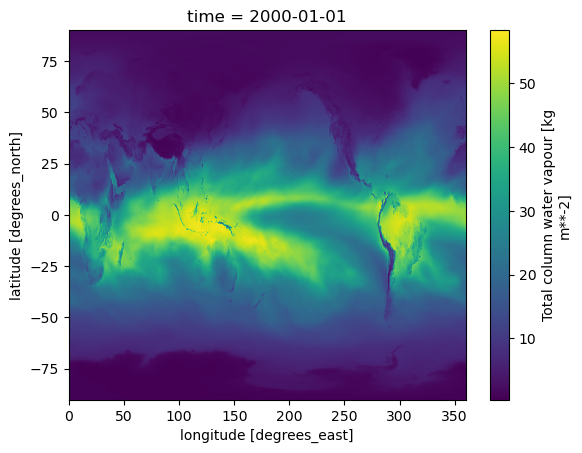

In [25]:
era_tcwv_dataset['TCWV'].isel(time=0).plot();

### Compare to processed data from hourly field

In [8]:
era_iwv_fromhourly = xr.open_dataset('/glade/campaign/cgd/ccr/kdagon/cgnet/ERA5/ERA5_IWV_monthly_2000-2014.nc')
era_iwv_fromhourly

<xarray.Dataset> Size: 1GB
Dimensions:    (longitude: 1440, latitude: 721, time: 180)
Coordinates:
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * time       (time) datetime64[ns] 1kB 2000-01-31 2000-02-29 ... 2014-12-31
Data variables:
    tcwv       (time, latitude, longitude) float64 1GB ...

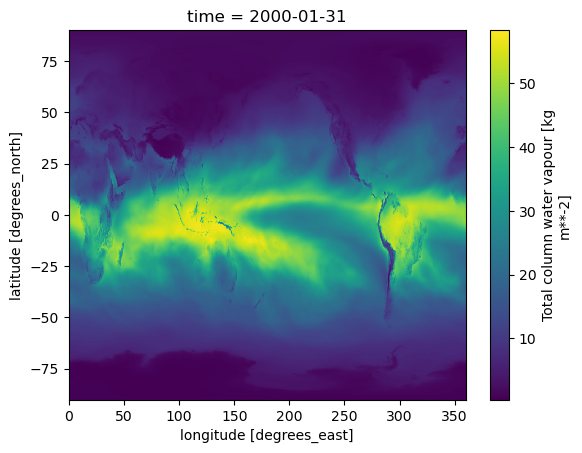

In [9]:
era_iwv_fromhourly['tcwv'].isel(time=0).plot();

#### Check diff

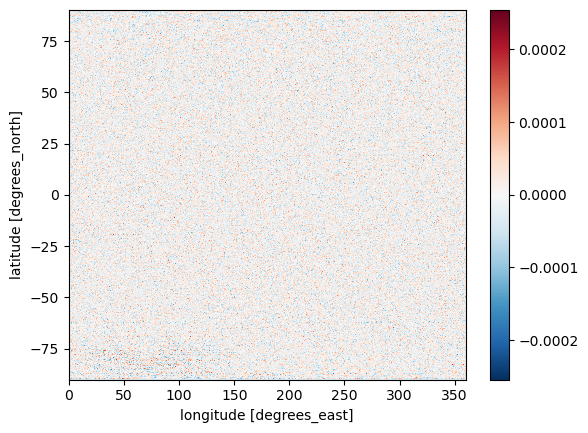

In [10]:
(era_iwv_fromhourly['tcwv'].mean(dim='time') - era_iwv_dataset['TCWV'].mean(dim='time')).plot();

### Global mean

In [32]:
era_tcwv = era_tcwv_dataset['TCWV']

In [33]:
era_tcwv_mean = era_tcwv.mean(dim='time')

In [34]:
print('ERA TCWV bounds are', era_tcwv_mean.min().values, era_tcwv_mean.max().values)

ERA TCWV bounds are 0.24816723 58.583492


In [35]:
era_weights = np.cos(np.deg2rad(era_tcwv.latitude))
era_weights.name = "weights"

In [36]:
era_tcwv_weighted = era_tcwv.weighted(era_weights)
era_tcwv_weighted

DataArrayWeighted with weights along dimensions: latitude

In [37]:
era_tcwv_gmean = era_tcwv_weighted.mean(("longitude", "latitude"))
era_tcwv_gmean

<xarray.DataArray 'TCWV' (time: 180)> Size: 1kB
dask.array<truediv, shape=(180,), dtype=float64, chunksize=(3,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 1kB 2000-01-01 2000-02-01 ... 2014-12-01

## MERRA Monthly data

In [11]:
def preprocess_TQV(ds):
    return ds['TQV']

In [12]:
#merra_iwv_full = xr.open_dataset("/glade/campaign/cgd/ccr/kdagon/cgnet/MERRA-2/MERRA2_IWV_monthly_2000-2015.nc") # ARTMIP-derived TMQ that I processed into monthly from 3hourly
merra_tqv_full = xr.open_mfdataset("/glade/campaign/cgd/ccr/kdagon/cgnet/MERRA-2/monthly_data_download/*.nc", concat_dim='time', combine='nested', parallel=True, preprocess=preprocess_TQV) # MERRA-2 direct download monthly TQV

In [13]:
merra_tqv_full

<xarray.DataArray 'TQV' (time: 192, lat: 361, lon: 576)> Size: 160MB
dask.array<concatenate, shape=(192, 361, 576), dtype=float32, chunksize=(1, 113, 576), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 2kB 2000-01-01T00:30:00 ... 2015-12-01T00:...
  * lon      (lon) float64 5kB -180.0 -179.4 -178.8 -178.1 ... 178.1 178.8 179.4
  * lat      (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5 90.0
Attributes:
    long_name:       total_precipitable_water_vapor
    units:           kg m-2
    fmissing_value:  1000000000000000.0
    vmax:            1000000000000000.0
    vmin:            -1000000000000000.0

In [16]:
merra_tqv = merra_tqv_full.sel(time=slice("2000","2014"))
merra_tqv

<xarray.DataArray 'TQV' (time: 180, lat: 361, lon: 576)> Size: 150MB
dask.array<getitem, shape=(180, 361, 576), dtype=float32, chunksize=(1, 113, 576), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 1kB 2000-01-01T00:30:00 ... 2014-12-01T00:...
  * lon      (lon) float64 5kB -180.0 -179.4 -178.8 -178.1 ... 178.1 178.8 179.4
  * lat      (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5 90.0
Attributes:
    long_name:       total_precipitable_water_vapor
    units:           kg m-2
    fmissing_value:  1000000000000000.0
    vmax:            1000000000000000.0
    vmin:            -1000000000000000.0

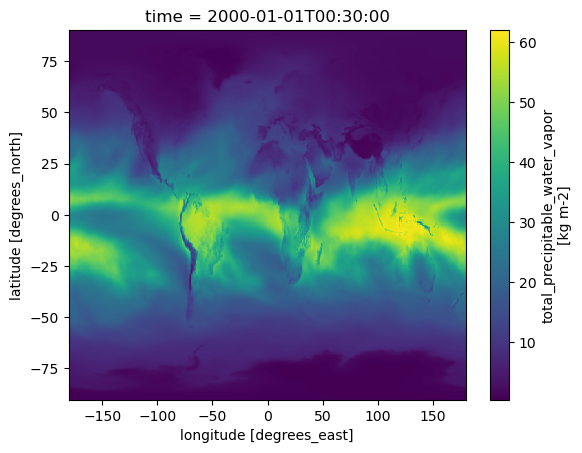

In [17]:
merra_tqv.isel(time=0).plot();

### Global Mean

In [18]:
merra_tqv_mean = merra_tqv.mean(dim='time')

In [19]:
print('MERRA TQV bounds are', merra_tqv_mean.min().values, merra_tqv_mean.max().values)

MERRA TQV bounds are 0.24085759 59.71703


In [20]:
merra_weights = np.cos(np.deg2rad(merra_tqv.lat))
merra_weights.name = "weights"

In [21]:
merra_tqv_weighted = merra_tqv_dataset.weighted(merra_weights)
merra_tqv_weighted

DataArrayWeighted with weights along dimensions: lat

In [22]:
merra_tqv_gmean = merra_tqv_weighted.mean(("lon", "lat"))
merra_tqv_gmean

<xarray.DataArray 'TQV' (time: 180)> Size: 1kB
dask.array<truediv, shape=(180,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 1kB 2000-01-01T00:30:00 ... 2014-12-01T00:...

## Plot running means comparison

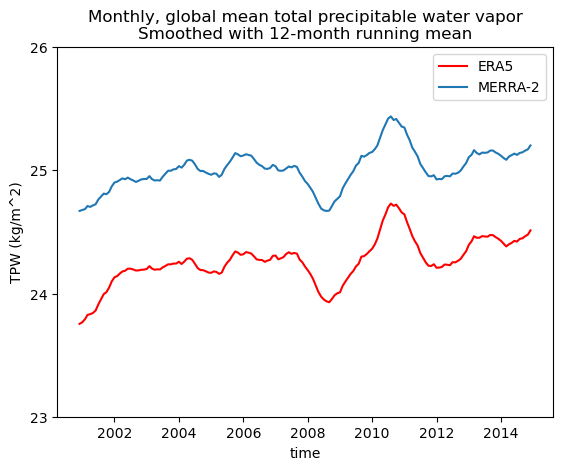

In [46]:
era_tcwv_gmean.rolling(time=12).mean().plot(label='ERA5', color='red')
merra_tqv_gmean.rolling(time=12).mean().plot(label='MERRA-2', color='C0')
plt.ylabel('TPW (kg/m^2)')
plt.yticks([23, 24, 25, 26])
plt.legend()
plt.title('Monthly, global mean total precipitable water vapor\nSmoothed with 12-month running mean')
plt.savefig('../figures/toSCP/ERA-MERRA-TPW_gmean_running_2000-2014.png', bbox_inches='tight')

## Comparing ERA/MERRA

### Remap ERA to MERRA grid
Upscaling instead of downscaling reanalysis

In [48]:
%%time
regridder_era_merra = xe.Regridder(era_tcwv, merra_tqv, "bilinear", periodic=True)
regridder_era_merra

CPU times: user 14.8 s, sys: 589 ms, total: 15.3 s
Wall time: 15.7 s


xESMF Regridder 
Regridding algorithm:       bilinear 
Weight filename:            bilinear_721x1440_361x576_peri.nc 
Reuse pre-computed weights? False 
Input grid shape:           (721, 1440) 
Output grid shape:          (361, 576) 
Periodic in longitude?      True

In [49]:
%%time
era_tcwv_merragrid = regridder_era_merra(era_tcwv, keep_attrs=True)
era_tcwv_merragrid

CPU times: user 1.87 s, sys: 201 ms, total: 2.07 s
Wall time: 4.42 s


<xarray.DataArray 'TCWV' (time: 180, lat: 361, lon: 576)> Size: 150MB
dask.array<astype, shape=(180, 361, 576), dtype=float32, chunksize=(3, 361, 576), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 1kB 2000-01-01 2000-02-01 ... 2014-12-01
  * lon      (lon) float64 5kB -180.0 -179.4 -178.8 -178.1 ... 178.1 178.8 179.4
  * lat      (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5 90.0
Attributes: (12/15)
    long_name:                     Total column water vapour
    short_name:                    tcwv
    units:                         kg m**-2
    original_format:               WMO GRIB 1 with ECMWF local table
    ecmwf_local_table:             128
    ecmwf_parameter:               137
    ...                            ...
    rda_dataset:                   ds633.1
    rda_dataset_url:               https:/rda.ucar.edu/datasets/ds633.1/
    rda_dataset_doi:               DOI: 10.5065/P8GT-0R61
    rda_dataset_group:             ERA5 monthly mean atmospheric surface anal...
    number_of_significant_digits:  7
    regrid_method:                 bilinear

/glade/work/kdagon/conda-envs/PEx_v2/lib/python3.11/site-packages/distributed/client.py:3162: UserWarning: Sending large graph of size 19.04 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


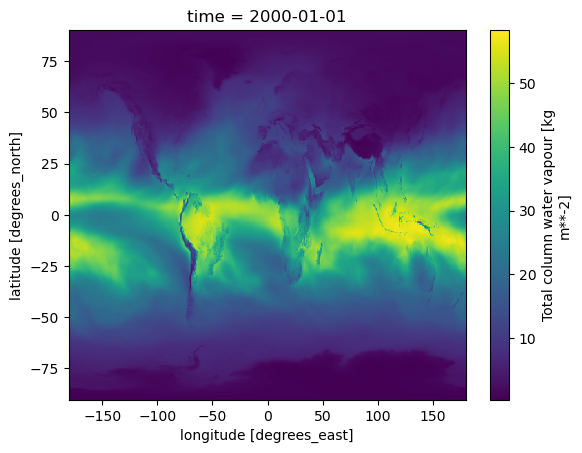

In [50]:
era_tcwv_merragrid.isel(time=0).plot();

In [51]:
era_tcwv_merragrid_mean = era_tcwv_merragrid.mean(dim='time')

In [52]:
print('ERA TCWV bounds are', era_tcwv_merragrid_mean.min().values, era_tcwv_merragrid_mean.max().values)

/glade/work/kdagon/conda-envs/PEx_v2/lib/python3.11/site-packages/distributed/client.py:3162: UserWarning: Sending large graph of size 19.12 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/glade/work/kdagon/conda-envs/PEx_v2/lib/python3.11/site-packages/distributed/client.py:3162: UserWarning: Sending large graph of size 19.12 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


ERA TCWV bounds are 0.24828127 58.583492


### Annual Differences, MERRA - ERA

In [53]:
IWV_merra_era_diff = merra_tqv_mean - era_tcwv_merragrid_mean

In [54]:
print('IWV diffs are ', IWV_merra_era_diff.min().values, IWV_merra_era_diff.max().values)

/glade/work/kdagon/conda-envs/PEx_v2/lib/python3.11/site-packages/distributed/client.py:3162: UserWarning: Sending large graph of size 19.46 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/glade/work/kdagon/conda-envs/PEx_v2/lib/python3.11/site-packages/distributed/client.py:3162: UserWarning: Sending large graph of size 19.46 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


IWV diffs are  -7.185589 11.401886


/glade/derecho/scratch/kdagon/tmp/ipykernel_512/431785001.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap=plt.cm.get_cmap('YlGn',12)
/glade/work/kdagon/conda-envs/PEx_v2/lib/python3.11/site-packages/distributed/client.py:3162: UserWarning: Sending large graph of size 19.12 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/glade/derecho/scratch/kdagon/tmp/ipykernel_512/431785001.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_d=plt.cm.get_cmap('BrBG')
/glade/work/kdagon/conda-envs/PEx_v2/lib/python3.11/site-packages/distributed/client.py:3162: UserWarning: Sending larg

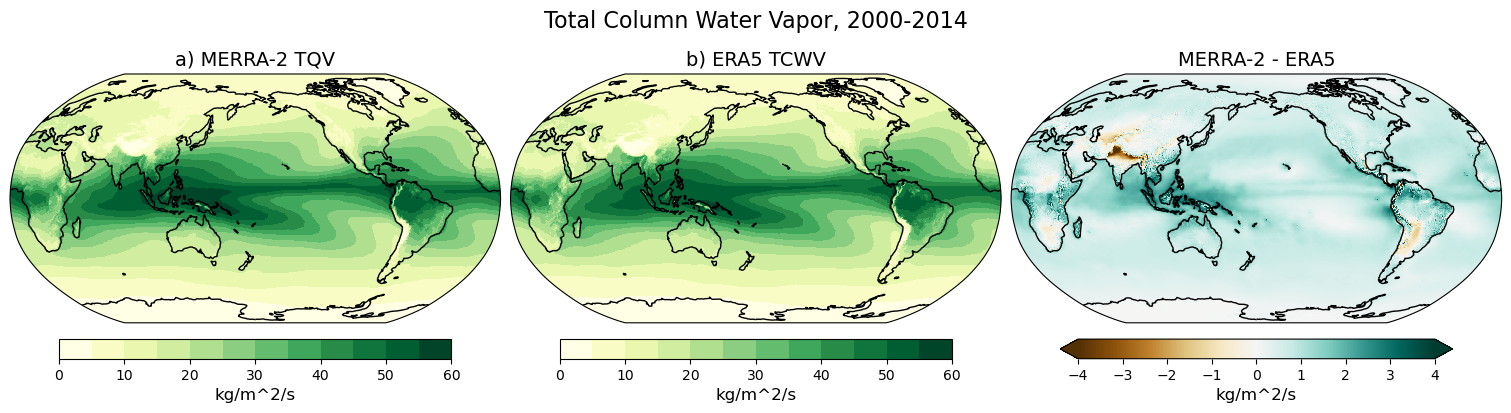

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), subplot_kw={'projection': ccrs.Robinson(central_longitude=180.0)}, constrained_layout=True)  # 1 row, 3 columns

# define coordinates throughout
lat = IWV_merra_era_diff.lat
lon = IWV_merra_era_diff.lon

# Absolute cmap
cmap=plt.cm.get_cmap('YlGn',12)
vmin=0
vmax=60

# MERRA
pc_m = axes[0].pcolormesh(lon, lat, merra_tqv_mean, cmap=cmap, vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
axes[0].coastlines()
axes[0].set_title('a) MERRA-2 TQV', fontsize=14)

# ERA
pc_e = axes[1].pcolormesh(lon, lat, era_tcwv_merragrid_mean, cmap=cmap, vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
axes[1].coastlines()
axes[1].set_title('b) ERA5 TCWV', fontsize=14)

# Diff cmap
cmap_d=plt.cm.get_cmap('BrBG')
vmin_d=-4
vmax_d=4

# IWV diff
pc_d = axes[2].pcolormesh(lon, lat, IWV_merra_era_diff, cmap=cmap_d, vmin=vmin_d, vmax=vmax_d, transform=ccrs.PlateCarree())
axes[2].coastlines()
axes[2].set_title('MERRA-2 - ERA5', fontsize=14)

# add absolute colorbar
#cbar_ax = fig.add_axes([0.2, 0.1, 0.2, 0.03]) #(left, bottom, width, height)
#cbar = plt.colorbar(pc_m, cax=cbar_ax, orientation='horizontal')
cbar = fig.colorbar(pc_m, ax=axes[0], location='bottom', shrink=0.8)
cbar.ax.set_xlabel('kg/m^2/s', fontsize=12)

# second panel colorbar
#cbar_ax = fig.add_axes([0.5, 0.15, 0.2, 0.03]) #(left, bottom, width, height)
#cbar = plt.colorbar(pc_u, cax=cbar_ax, orientation='horizontal')
cbar = fig.colorbar(pc_e, ax=axes[1], location='bottom', shrink=0.8)
cbar.ax.set_xlabel('kg/m^2/s', fontsize=12)

# add diff colorbar
#cbar_ax = fig.add_axes([0.5, 0.15, 0.2, 0.03]) #(left, bottom, width, height)
#cbar = plt.colorbar(pc_u, cax=cbar_ax, orientation='horizontal')
cbar = fig.colorbar(pc_d, ax=axes[2], location='bottom', shrink=0.8, extend='both')
cbar.ax.set_xlabel('kg/m^2/s', fontsize=12)

# add suptitle
fig.suptitle('Total Column Water Vapor, 2000-2014', fontsize=16)

#plt.subplots_adjust(wspace=0.1, hspace=0.3)
#plt.tight_layout() # does not work with constrained_layout=True

#plt.savefig('../figures/toSCP/ERA-TCWV-MERRA-TQV_diffs_2000-2014.png', bbox_inches='tight')

### Global, Monthly differences

In [58]:
era_merragrid_weights = np.cos(np.deg2rad(era_tcwv_merragrid.lat))
era_merragrid_weights.name = "weights"

In [59]:
era_tcwv_merragrid_weighted = era_tcwv_merragrid.weighted(era_merragrid_weights)
era_tcwv_merragrid_weighted

DataArrayWeighted with weights along dimensions: lat

In [60]:
era_tcwv_merragrid_gmean = era_tcwv_merragrid_weighted.mean(("lon", "lat"))
era_tcwv_merragrid_gmean

<xarray.DataArray 'TCWV' (time: 180)> Size: 1kB
dask.array<truediv, shape=(180,), dtype=float64, chunksize=(3,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 1kB 2000-01-01 2000-02-01 ... 2014-12-01

/glade/work/kdagon/conda-envs/PEx_v2/lib/python3.11/site-packages/distributed/client.py:3162: UserWarning: Sending large graph of size 19.16 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


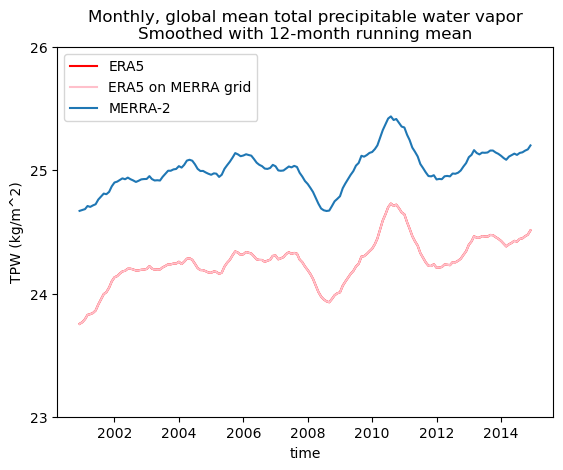

In [61]:
era_tcwv_gmean.rolling(time=12).mean().plot(label='ERA5', color='red')
era_tcwv_merragrid_gmean.rolling(time=12).mean().plot(label='ERA5 on MERRA grid', color='pink')
merra_tqv_gmean.rolling(time=12).mean().plot(label='MERRA-2', color='C0')
plt.ylabel('TPW (kg/m^2)')
plt.yticks([23, 24, 25, 26])
plt.legend()
plt.title('Monthly, global mean total precipitable water vapor\nSmoothed with 12-month running mean')
#plt.savefig('../figures/toSCP/ERA-MERRA-TPW_gmean_running_withregrid_2000-2014.png', bbox_inches='tight')

In [62]:
client.close()
cluster.close()